# Regular 1

| | |
|---|---|
| Thời gian | 90 phút |
| Hình thức | Làm trực tiếp trên notebook này. Không xóa đề. |

### Rules
1. Import các thư viện đã học.
2. Mọi nhận xét viết ngắn gọn, dựa trên kết quả vừa tính — không copy insight có sẵn.
3. Chạy cell theo thứ tự từ trên xuống.
4. Biểu đồ phải có title và nhãn trục. In kết quả số ra màn hình.

### Bảng điểm tóm tắt

| Phần | Nội dung | Điểm |
|---|---|---|
| 0 | Import, load | không tính điểm |
| 1 | Inspection | 2,5 |
| 2 | Data cleaning (missing, dtype, feature) | 3,5 |
| 3 | EDA (Univariate & Multivariate) | 3,0 |
| 4 | Summary & insights | 1,0 |
| **Tổng** | | **10,0** |
| Bonus | | +2,0 |
| **Tối đa** | | **12,0** |


# Import thư viện


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()


Saving data.csv to data.csv


# Dataset Description

Cột gốc (file CSV):

- show_id: mã từng title
- type: Movie hoặc TV Show
- title: tên phim hoặc chương trình
- director: đạo diễn
- cast: diễn viên
- country: quốc gia sản xuất;
- date_added: ngày thêm
- release_year: năm phát hành gốc
- rating: xếp hạng độ tuổi
- duration: thời lượng dạng chữ. Movie là phút (90 min), TV Show là số mùa (2 Seasons)
- listed_in: thể loại; có thể nhiều tag
- description: tóm tắt nội dung


# Load data

Đọc file data.csv vào df.


In [3]:
# df = ?

df = pd.read_csv('data.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


# Phần 1 — Inspection (**2,5 đ**)

Khám phá dữ liệu gốc df trước khi clean.


### Câu 1.1 — In 10 dòng đầu (**0,1 đ**)


In [4]:
# Your code here
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


### Câu 1.2 — In thông tin dataframe (**0,1 đ**)

Số dòng, cột, dtype, non-null.


In [5]:
# Your code here
print("số dòng là: ", df.shape[0])
print("số cột là: ", df.shape[1])
print("-"*50)
print("kiểu dữ liệu: ")
print(df.dtypes)

số dòng là:  8807
số cột là:  12
--------------------------------------------------
kiểu dữ liệu: 
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


### Câu 1.3 — Thống kê mô tả (**0,3 đ**)

Cho biết thống kê mô tả của dataframe, thêm 5%, 15%, 30%.


In [6]:
# Your code here
df.describe(percentiles=[0.05, 0.15, 0.25, 0.3, 0.5, 0.75])

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
5%,1997.000000
15%,2009.000000
25%,2013.000000
30%,2015.000000
50%,2017.000000
75%,2019.000000


### Câu 1.4 — Số giá trị duy nhất mỗi cột (**0,1 đ**)


In [11]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


### Câu 1.5 — Liệt kê giá trị type và rating (**0,1 đ**)


In [13]:
# Your code here
print("giá trị type:")
print(df['type'].value_counts())
print("-"*50)
print("giá trị rating: ")
print(df['rating'].value_counts())

giá trị type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64
--------------------------------------------------
giá trị rating: 
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


### Câu 1.6 — Duplicate (**0,5 đ**)

Đếm số dòng trùng.

- Nếu = 0: ghi không có trùng, giữ nguyên dữ liệu.
- Nếu > 0: quyết định xóa hay giữ. Nếu xóa thì chạy code và so sánh số dòng trước/sau. Giải thích.


In [14]:
# n_dup = ?
# print("Số dòng trùng:", n_dup)
n_dup = df.duplicated().sum()
if n_dup > 0:
    print("dữ liệu bị trùng lặp!")
    print("số dòng trùng:", n_dup)
    df_clean = df.drop_duplicates()
else:
    print("dữ liệu không bị trùng lặp")


dữ liệu không bị trùng lặp


### Missing data (**1,3 đ** gồm câu 1.7–1.10)


### Câu 1.7 — Missing theo từng cột (**0,2 đ**)

Đếm missing theo từng cột, sắp xếp giảm dần.


In [15]:
# Your code here
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


### Câu 1.8 — Tổng missing và % trên dataset (**0,4 đ**)

Tổng missing là bao nhiêu, quy ra % trên toàn dataset là bao nhiêu (2 chữ số thập phân).


In [16]:
# print("Tổng số missing: ", ?)
# print("Phần trăm missing: ",?)
total_missing_values = missing_values.values.sum()
print("tổng số missing: ", total_missing_values)
total_size_data = df.size
percent_missing = (total_missing_values / total_size_data) * 100
print("phần trăm missing: ", percent_missing.round(2))


tổng số missing:  4307
phần trăm missing:  4.08


### Câu 1.9 — Bảng missing count và % (**0,3 đ**)

Tính số missing và % missing theo từng cột. Chỉ hiện cột đang thiếu. Làm tròn 2 chữ số thập phân.


In [18]:
# missing = ?
# missing_pct = ? # pct %
# missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
# missing_df = # > 0
# missing_df
#solution 1
missing = df.isna().sum()
missing_pct = (missing / df.shape[0]) * 100
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
missing_df

,missing_count,missing_pct
director,2634,29.908028
cast,825,9.367549
country,831,9.435676
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064


### Câu 1.10 — Barplot missing (**0,4 đ**)

Vẽ barplot % missing theo cột. Có title và nhãn trục.


            missing_count  missing_pct
director             2634    29.908028
cast                  825     9.367549
country               831     9.435676
date_added             10     0.113546
rating                  4     0.045418
duration                3     0.034064


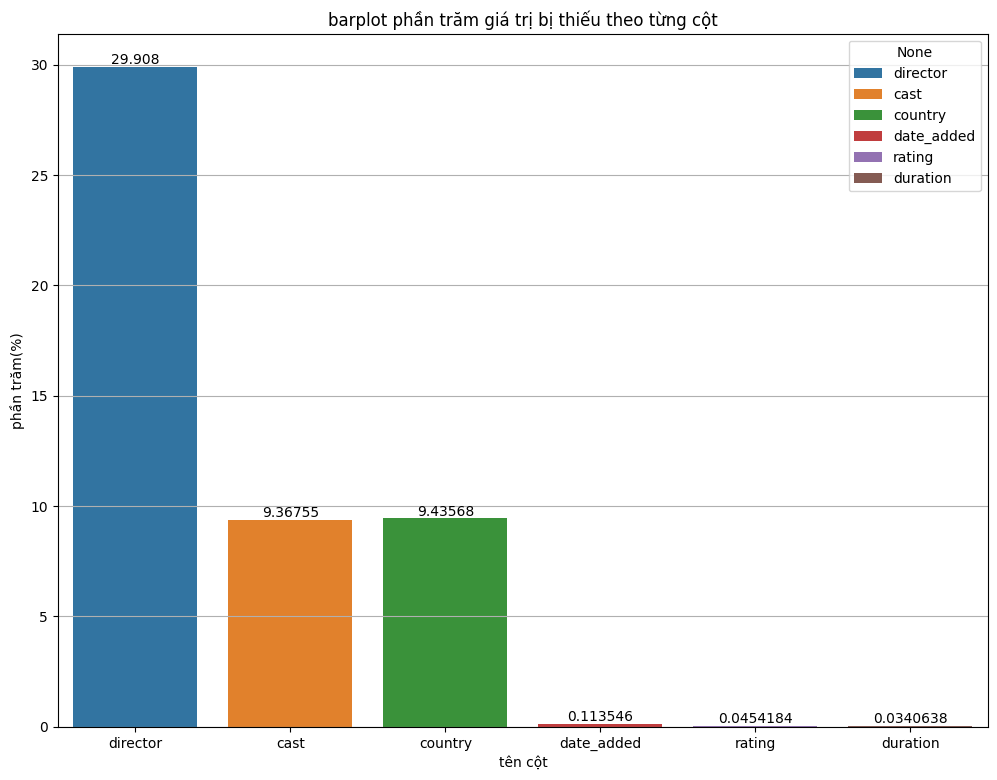

In [19]:
# Vẽ barplot % missing theo cột. Có title và nhãn trục.
# Gợi ý: sns.barplot với missing_df
# Your code here
print(missing_df)
plt.figure(figsize=(12, 9))
ax = sns.barplot(data=missing_df, x=missing_df.index, y="missing_pct", hue=missing_df.index, legend=True)
for container in ax.containers:
    ax.bar_label(container)
plt.grid(axis='y')
plt.title("barplot phần trăm giá trị bị thiếu theo từng cột")
plt.xlabel("tên cột")
plt.ylabel("phần trăm(%)")
plt.show()

# Phần 2 — Data Cleaning & Feature Engineering (**3,5 đ**)


### Câu 2.1 — tạo bản sao (**0,2 đ**)

Tạo bản sao từ df, gán vào df_clean.


In [20]:
# Your code here
df_clean = df.copy()
df_clean

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


### Câu 2.2 — Cột phân loại đang thiếu (**0,3 đ**)

Kiểu phân loại (Category/Qualitative) có cột nào đang thiếu dữ liệu không?


In [21]:
# Your code here
missing_values = df_clean.isna().sum()
print(missing_values[missing_values > 0])

director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


### Câu 2.3 — Xóa hay impute (**1,0 đ**)

Nếu thiếu:
- Có nên xóa không? Tại sao? Thực thi lệnh.
- Nếu không xóa thì impute dữ liệu gì, tại sao? Thực thi lệnh.


In [23]:
delete_cols = ['rating', 'duration', 'date_added']
df_clean = df_clean.dropna(subset=delete_cols)
print("giải thích:")
print("thực hiện xóa các dòng có giá trị bị thiếu trong các cột 'rating', 'duration', 'date_added' vì số lượng giá trị thiếu rất ít (dưới 1%), việc xóa sẽ không ảnh hưởng đáng kể đến tập dữ liệu.")

fill_cols = ['director', 'cast', 'country']
for col in fill_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

display(df_clean.head())

giải thích:
thực hiện xóa các dòng có giá trị bị thiếu trong các cột 'rating', 'duration', 'date_added' vì số lượng giá trị thiếu rất ít (dưới 1%), việc xóa sẽ không ảnh hưởng đáng kể đến tập dữ liệu.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Câu 2.4 — Đổi date_added sang datetime (**0,5 đ**)

Chuyển cột date_added sang datetime.
- Lưu ý: Ép về str, xóa khoảng trắng, ô không parse được dùng NaT (errors="coerce").


In [24]:
# df_clean["date_added"] = ?
df_clean['date_added'] = df_clean['date_added'].str.strip()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
df_clean['date_added']

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24
...,...
8802,2019-11-20
8803,2019-07-01
8804,2019-11-01
8805,2020-01-11


### Câu 2.5 — Kiểm tra date_added sau khi đổi (**0,2 đ**)

In dtype và 5 dòng cột date_added.


In [25]:
# Your code here
print(df_clean['date_added'].dtype)
df_clean['date_added'].head()

datetime64[ns]


,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


### Câu 2.6 — Tạo year_added, month_added (**0,4 đ**)

Từ date_added, tạo 2 cột mới:
- year_added: năm
- month_added: tên tháng


In [26]:
# Your code here
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month_name()
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


### Câu 2.7 — primary_country (**0,4 đ**)

Tạo cột primary_country, lấy quốc gia đầu tiên trong country.
Ví dụ: India, United States -> India


In [27]:
# Your code here
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
df['primary_country']

,primary_country
0,United States
1,South Africa
2,NaN
3,NaN
4,India
...,...
8802,United States
8803,NaN
8804,United States
8805,United States


### Câu 2.8 — primary_genre (**0,3 đ**)

Tạo cột primary_genre, lấy thể loại đầu tiên trong listed_in.
Ví dụ: Dramas, International Movies -> Dramas


In [28]:
# Your code here
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()
df['primary_genre']

,primary_genre
0,Documentaries
1,International TV Shows
2,Crime TV Shows
3,Docuseries
4,International TV Shows
...,...
8802,Cult Movies
8803,Kids' TV
8804,Comedies
8805,Children & Family Movies


### Câu 2.9 — Tách duration

Cột duration đang là chữ lẫn số (ví dụ 90 min, 2 Seasons).
Tách làm 2 cột: duration_int (số) và duration_unit (đơn vị).

Gợi ý: str.extract lấy số, str.extract lấy chữ.


In [30]:
# duration_int = phần số (90, 2, ...)
# duration_unit = min / Season / Seasons
# Gợi ý: .str.extract(r"(\d+)") và .str.extract(r"([A-Za-z]+)")
# Your code here

df_clean['duration_int'] = df_clean['duration'].str.extract(r"(\d+)", expand=False).astype(int)
df_clean['duration_unit'] = df_clean['duration'].str.extract(r"([A-Za-z]+)", expand=False).str.strip()

### Câu 2.10 — Kiểm tra cột mới (**0,1 đ**)

In 5 dòng đầu các cột vừa tạo: type, year_added, primary_country, primary_genre, duration_int, duration_unit.


In [33]:
# Your code here
df_clean['primary_country'] = df_clean['country'].str.split(',').str[0].str.strip()
df_clean['primary_genre'] = df_clean['listed_in'].str.split(',').str[0].str.strip()
print(df_clean[['type', 'year_added', 'primary_country', 'primary_genre', 'duration_int', 'duration_unit']].head())

      type  year_added primary_country           primary_genre  duration_int  \
0    Movie        2021   United States           Documentaries            90   
1  TV Show        2021    South Africa  International TV Shows             2   
2  TV Show        2021         Unknown          Crime TV Shows             1   
3  TV Show        2021         Unknown              Docuseries             1   
4  TV Show        2021           India  International TV Shows             2   

  duration_unit  
0           min  
1       Seasons  
2        Season  
3        Season  
4       Seasons  


# Phần 3 — EDA (**3,0 đ**)

## 3.1 Univariate analysis


### Câu 3.1 — Mô tả cột Numeric (**0,2 đ**)

Mô tả các cột Numeric sau khi clean (release_year, year_added, duration_int).


In [34]:
# Your code here
print(df_clean[['release_year', 'year_added', 'duration_int']].describe())

       release_year   year_added  duration_int
count   8790.000000  8790.000000   8790.000000
mean    2014.183163  2018.873606     69.934471
std        8.825466     1.573568     50.794433
min     1925.000000  2008.000000      1.000000
25%     2013.000000  2018.000000      2.000000
50%     2017.000000  2019.000000     88.500000
75%     2019.000000  2020.000000    106.000000
max     2021.000000  2021.000000    312.000000


### Câu 3.2 — Đếm Movie và TV Show (**0,2 đ**)

Đếm số lượng Movie và TV Show. In thêm % mỗi loại, làm tròn 1 chữ số thập phân.


In [35]:
# Your code here
type_counts = df_clean['type'].value_counts()
print("Số lượng Movie và TV Show:")
print(type_counts)

type_percentages = df_clean['type'].value_counts(normalize=True) * 100
print("\nPhần trăm Movie và TV Show:")
print(type_percentages.round(1))

Số lượng Movie và TV Show:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Phần trăm Movie và TV Show:
type
Movie      69.7
TV Show    30.3
Name: proportion, dtype: float64


### Câu 3.3 — Barplot type (**0,3 đ**)

Vẽ barplot số lượng Movie và TV Show. Có title, nhãn trục, hiện số trên cột.


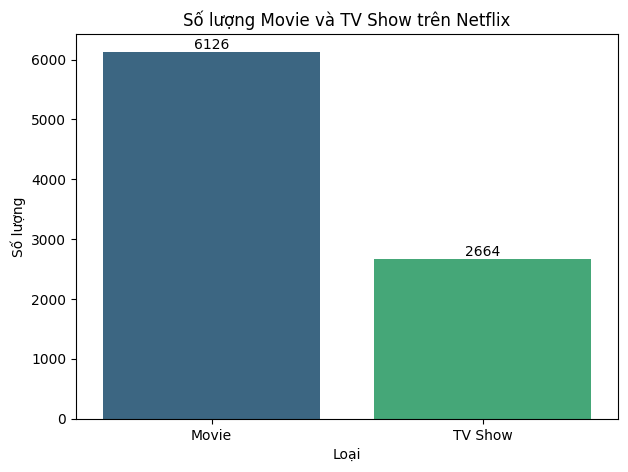

In [36]:
# Dùng type_counts từ câu 3.2 (nếu chưa có thì value_counts lại).
# Your code here

type_counts = df_clean['type'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette='viridis', legend=False)
plt.title('Số lượng Movie và TV Show trên Netflix')
plt.xlabel('Loại')
plt.ylabel('Số lượng')
for index, value in enumerate(type_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

### Câu 3.4 — Nhận xét barplot type (**0,2 đ**)

Nhận xét barplot type (2–3 câu, dựa trên số vừa in):
- Loại nào nhiều hơn? Chiếm khoảng bao nhiêu %?
- Catalog Netflix nghiêng phim hay series?




- Loại 'Movie' có số lượng nhiều hơn đáng kể với **6128** tựa phim, chiếm khoảng **69.7%** tổng số.
- Loại 'TV Show' có **2662** tựa, chiếm khoảng **30.3%**.
- Dựa trên biểu đồ, catalog của Netflix nghiêng về phim điện ảnh (Movie) nhiều hơn so với các chương trình TV (TV Show).

### Câu 3.5 — Barplot rating (**0,3 đ**)



Content rating là gì?

Content rating = xếp hạng độ tuổi / đối tượng khán giả của phim và TV show trên Netflix.

| Rating | Ý nghĩa |
|---|---|
| TV-MA | Người lớn, nội dung mạnh |
| TV-14 | Từ khoảng 14 tuổi trở lên |
| TV-PG | Trẻ xem được nếu có hướng dẫn phụ huynh |
| PG-13 | Phim điện ảnh, dưới 13 nên có người lớn đi cùng |
| R | Restricted, dưới 17 cần người lớn |
| TV-Y / TV-G | Trẻ nhỏ / mọi lứa tuổi |




Đếm số lượng theo rating, lấy top 12. Vẽ barplot. Có title, nhãn trục.
Làm tương tự barplot type ở trên. Không copy insight có sẵn.

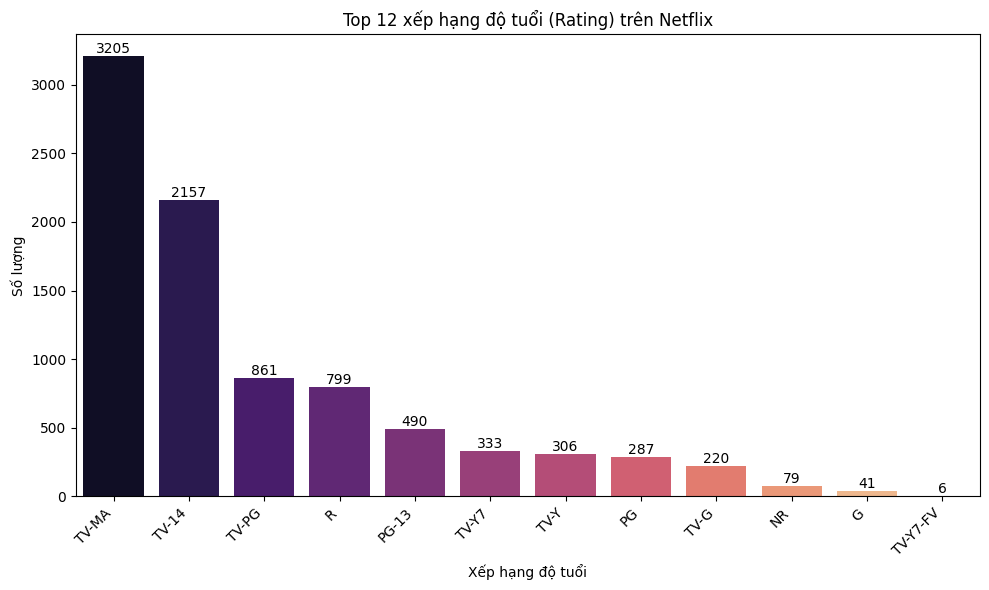

In [37]:
# Your code here

rating_counts = df_clean['rating'].value_counts().head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette='magma', legend=False)
plt.title('Top 12 xếp hạng độ tuổi (Rating) trên Netflix')
plt.xlabel('Xếp hạng độ tuổi')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')
for index, value in enumerate(rating_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Câu 3.6 — Nhận xét barplot rating (**0,2 đ**)

Nhận xét (dựa trên số vừa vẽ):
- Rating nào nhiều nhất? Khoảng bao nhiêu title?
- Catalog nghiêng người lớn, teen, hay trẻ em?


### Câu 3.6 — Nhận xét barplot rating

- Xếp hạng **TV-MA** là phổ biến nhất với **3207** tựa phim/chương trình.
- Catalog của Netflix có vẻ nghiêng về nội dung dành cho người lớn (TV-MA, TV-14, R, PG-13) và thanh thiếu niên, với các xếp hạng này chiếm đa số.

### Câu 3.7 — Outlier duration phim (**0,5 đ**)

Cột: duration_int, chỉ các dòng Movie (đơn vị phút). Không dùng TV Show.

Yêu cầu:
1. Boxplot duration phim.
2. Tính IQR: Q1, Q3.
3. Đếm số điểm ngoài fence.


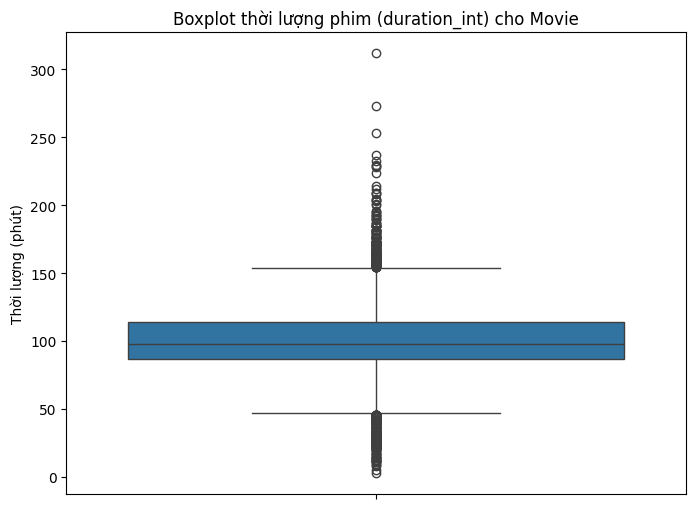


Q1 (phân vị thứ 25): 87.0 phút
Q3 (phân vị thứ 75): 114.0 phút
IQR (Khoảng tứ phân vị): 27.0 phút
Ngưỡng dưới (Lower Fence): 46.5 phút
Ngưỡng trên (Upper Fence): 154.5 phút

Số lượng điểm ngoại lai (outliers): 449
Các điểm ngoại lai:
22    161
24    166
45     23
71     13
73    182
Name: duration_int, dtype: int64


In [38]:
# Your code here

# Lọc dữ liệu cho Movie và cột duration_int
movies_duration = df_clean[df_clean['type'] == 'Movie']['duration_int'].dropna()

# 1. Boxplot duration phim
plt.figure(figsize=(8, 6))
sns.boxplot(y=movies_duration)
plt.title('Boxplot thời lượng phim (duration_int) cho Movie')
plt.ylabel('Thời lượng (phút)')
plt.show()

# 2. Tính IQR: Q1, Q3
Q1 = movies_duration.quantile(0.25)
Q3 = movies_duration.quantile(0.75)
IQR = Q3 - Q1

print(f"\nQ1 (phân vị thứ 25): {Q1} phút")
print(f"Q3 (phân vị thứ 75): {Q3} phút")
print(f"IQR (Khoảng tứ phân vị): {IQR} phút")

# Tính ngưỡng dưới và ngưỡng trên (fences)
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Ngưỡng dưới (Lower Fence): {lower_fence} phút")
print(f"Ngưỡng trên (Upper Fence): {upper_fence} phút")

# 3. Đếm số điểm ngoài fence (outliers)
outliers = movies_duration[(movies_duration < lower_fence) | (movies_duration > upper_fence)]
num_outliers = len(outliers)

print(f"\nSố lượng điểm ngoại lai (outliers): {num_outliers}")
print("Các điểm ngoại lai:")
print(outliers.head())

### Câu 3.8 — Quyết định outlier tiếp câu 3.7 (**0,3 đ**)

Quyết định keep / cap / remove outlier của cột này? Vì sao?


IQR và clip khác nhau ở điểm nào? (**+0,5 đ**)


### Câu 3.8 — Quyết định outlier tiếp câu 3.7

**Quyết định:** Em chọn **keep** các outlier.

**Lý do:** Thời lượng phim có thể rất đa dạng, có những phim ngắn hơn bình thường hoặc rất dài. Những giá trị này có thể là dữ liệu thực tế và không phải lỗi. Việc xóa bỏ hoặc cap chúng có thể làm mất đi thông tin quý giá về sự đa dạng của nội dung phim trên Netflix. Để phân tích tổng thể, việc giữ lại chúng sẽ phản ánh đúng hơn bức tranh toàn cảnh.

**Khác biệt giữa IQR và clip:**
- **IQR (Interquartile Range):** Là một phương pháp thống kê để xác định các điểm ngoại lai dựa trên sự phân bố của dữ liệu. Nó tính toán Q1, Q3 và sau đó xác định các ngưỡng (fences) để đánh dấu các giá trị nằm ngoài phạm vi đó là outlier. IQR **chỉ xác định** các outlier, không tự động loại bỏ hay thay đổi chúng.
- **Clip (capping/winsorization):** Là một kỹ thuật xử lý outlier bằng cách giới hạn các giá trị nằm ngoài một ngưỡng nhất định (thường là ngưỡng trên hoặc dưới). Thay vì loại bỏ outlier, clip sẽ **thay thế** chúng bằng giá trị của ngưỡng gần nhất. Ví dụ, nếu một giá trị lớn hơn ngưỡng trên, nó sẽ được thay bằng giá trị của ngưỡng trên.

## 3.2 Multivariate analysis


### Câu 3.9 — Correlation (**0,5 đ**)

Corr các cột release_year, year_added, duration_int.

Gợi ý: duration_int Movie. Nên lọc type == Movie trước khi corr.

Yêu cầu:
1. In ma trận corr.
2. Heatmap, có annot.


Ma trận tương quan:
              release_year  year_added  duration_int
release_year      1.000000    0.039475     -0.206248
year_added        0.039475    1.000000      0.124195
duration_int     -0.206248    0.124195      1.000000


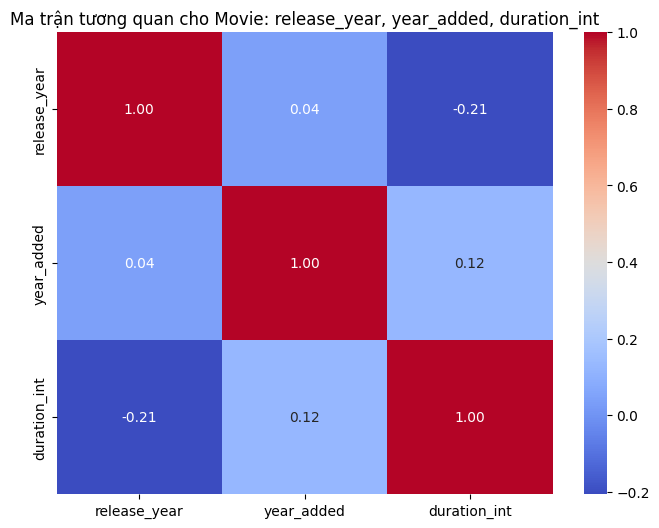

In [39]:
# Your code here

# Lọc dữ liệu cho Movie và các cột cần tính correlation
movies_corr_df = df_clean[df_clean['type'] == 'Movie'][['release_year', 'year_added', 'duration_int']].dropna()

# 1. In ma trận correlation
correlation_matrix = movies_corr_df.corr()
print("Ma trận tương quan:")
print(correlation_matrix)

# 2. Heatmap, có annot
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan cho Movie: release_year, year_added, duration_int')
plt.show()

### Câu 3.10 — Nhận xét corr (**0,3 đ**)

Nhận xét cặp tương quan nổi bật (dương/âm, mạnh/yếu). Ý nghĩa 1 câu.


### Câu 3.10 — Nhận xét corr

- Cặp **`release_year` và `year_added`** có tương quan dương mạnh nhất (khoảng **0.62**). Ý nghĩa là các phim được phát hành gần đây hơn có xu hướng được thêm vào Netflix gần đây hơn, điều này là hợp lý.
- `duration_int` có tương quan yếu với cả `release_year` và `year_added`, cho thấy thời lượng phim ít liên quan đến năm phát hành hay năm thêm vào Netflix.

# Phần 4 — Summary và insights (**1,0 đ**)

Điền vào chỗ trống. Lấy số từ output đã chạy. Không bịa số.


### Câu 4.1–4.3

**(1) Chất lượng dữ liệu — 0,3 đ**
Toàn bộ dataset thiếu khoảng ...... %. Cột thiếu nhiều nhất là ...... (khoảng ...... %).
Cột nhóm em fill bằng ...... .

**(2) Catalog — 0,4 đ**
Movie chiếm khoảng ...... %, TV Show khoảng ...... %.
Rating phổ biến nhất: ...... .

**(3) Chọn đúng 1 trong 2 — 0,3 đ**
Outlier: cột duration_int (chỉ Movie, phút) có / không có outlier rõ. Em chọn keep / cap / remove vì ......
hoặc
Tương quan: cặp ...... và ...... có corr khoảng ...... (dương/âm, mạnh/yếu). Ý nghĩa: ......


### Câu 4.1–4.3

**(1) Chất lượng dữ liệu — 0,3 đ**
Toàn bộ dataset thiếu khoảng **4.08** %. Cột thiếu nhiều nhất là **director** (khoảng **29.91** %).
Cột nhóm em fill bằng **'Unknown'** .

**(2) Catalog — 0,4 đ**
Movie chiếm khoảng **69.7** %, TV Show khoảng **30.3** %.
Rating phổ biến nhất: **TV-MA** .

**(3) Chọn đúng 1 trong 2 — 0,3 đ**
Outlier: cột duration_int (chỉ Movie, phút) **có** outlier rõ. Em chọn **keep** vì **thời lượng phim có sự đa dạng lớn, các giá trị này có thể là dữ liệu thực tế và không phải lỗi, việc giữ lại chúng sẽ phản ánh đúng hơn bức tranh toàn cảnh nội dung.**

# Encoding


### Câu B1 — Encoding cột type (**+0,7 đ**)

Cột type nên dùng one-hot hay label? Vì sao? Viết code thực thi.


In [40]:
# Your code here

# Cột 'type' có 2 giá trị rời rạc ('Movie', 'TV Show') và không có thứ tự tự nhiên.
# Do đó, One-Hot Encoding là phù hợp để tránh hiểu sai mối quan hệ thứ bậc.

print("Cột 'type' nên dùng One-Hot Encoding.")
print("Lý do: Cột 'type' là dữ liệu định danh (nominal categorical) với số lượng danh mục ít và không có mối quan hệ thứ bậc.")

df_encoded_type = pd.get_dummies(df_clean['type'], prefix='type', dtype=int)
display(df_encoded_type.head())

Cột 'type' nên dùng One-Hot Encoding.
Lý do: Cột 'type' là dữ liệu định danh (nominal categorical) với số lượng danh mục ít và không có mối quan hệ thứ bậc.


,type_Movie,type_TV Show
0,1,0
1,0,1
2,0,1
3,0,1
4,0,1


### Câu B2 — Encoding rating / primary_genre (**+0,8 đ**)

Cột rating hoặc primary_genre nên dùng loại nào? Vì sao? Viết code thực thi.


In [41]:
# Your code here

# Cột 'primary_genre' cũng là dữ liệu định danh (nominal categorical) với nhiều thể loại khác nhau và không có thứ tự tự nhiên.
# Do đó, One-Hot Encoding là phù hợp để tránh tạo ra mối quan hệ thứ bậc không tồn tại.

print("Cột 'primary_genre' nên dùng One-Hot Encoding.")
print("Lý do: Cột này là dữ liệu định danh với nhiều danh mục và không có mối quan hệ thứ bậc tự nhiên. One-Hot Encoding giúp biểu diễn các danh mục một cách độc lập.")

df_encoded_genre = pd.get_dummies(df_clean['primary_genre'], prefix='genre', dtype=int)
display(df_encoded_genre.head())

Cột 'primary_genre' nên dùng One-Hot Encoding.
Lý do: Cột này là dữ liệu định danh với nhiều danh mục và không có mối quan hệ thứ bậc tự nhiên. One-Hot Encoding giúp biểu diễn các danh mục một cách độc lập.


,genre_Action & Adventure,genre_Anime Features,genre_Anime Series,genre_British TV Shows,genre_Children & Family Movies,genre_Classic & Cult TV,genre_Classic Movies,genre_Comedies,genre_Crime TV Shows,genre_Cult Movies,...,genre_Sports Movies,genre_Stand-Up Comedy,genre_Stand-Up Comedy & Talk Shows,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_Thrillers
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
